### Import Modules


In [1]:
# Standard Library
import random, traceback
from collections.abc import Callable, Generator
from contextlib import contextmanager
from datetime import datetime, timezone
from IPython.display import display
from pathlib import Path
from typing import Any

# Must run before scikit-learn is imported.
def enable_cuml_acceleration() -> tuple[bool, str]:
    try:
        import cupy
        if cupy.cuda.runtime.getDeviceCount() >= 1:
            cupy.zeros(1).sum()

            import cuml.accel
            cuml.accel.install()

            return True, "on (GPU)"
        else:
            return False, "off (CPU)"
    except ImportError:
        return False, "off (CPU)"

    return False, f"off (CPU)"

CUML_ACCELERATED, CUML_STATUS = enable_cuml_acceleration()

# Packages
import mlflow, numpy, optuna, pandas, torch
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from matplotlib import pyplot, ticker
from matplotlib.figure import Figure
from mlflow import ActiveRun, MlflowClient
from mlflow.models import infer_signature, ModelSignature
from mlflow.models.model import ModelInfo
from mlflow.pyfunc import PythonModel, PythonModelContext
from numpy import ndarray
from optuna.samplers import TPESampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler
from torch import multiprocessing, nn, optim, Tensor
from torch.nn import functional
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from xgboost import XGBClassifier

C:\Users\Reaven\Projects\Personal\Practice\fraud-detection-platform\notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants & Config


In [2]:
# Paths
ROOT_DIR = Path("../").resolve()

# Data
TEST_SIZE = 0.2
START_DATE = datetime(2013, 9, 1, tzinfo=timezone.utc)
SEED_PATH = (
    ROOT_DIR
    / "database"
    / "seed"
    / "transaction_inferences"
    / "creditcard_transactions.csv.gz"
)

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
numpy.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Cross Validation
CV_VAL_SIZE = TEST_SIZE / (1 - TEST_SIZE)
CV = StratifiedKFold(
    n_splits=int(1 / CV_VAL_SIZE), shuffle=True, random_state=RANDOM_STATE
)

# Hyperparameter Optimization
BAYES_STEPS = 30
TRAINING_TIMEOUT_SECONDS = 3_600
ACTIVATION_MAP = {"relu": nn.ReLU, "gelu": nn.GELU, "silu": nn.SiLU}

# Torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE.type}")
print(f"cuML acceleration: {CUML_STATUS}")
multiprocessing.set_start_method("spawn", force=True)

# optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

# MLflow
MLFLOW_DIR = Path("./mlflow").resolve()
MLFLOW_DIR.mkdir(exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{(MLFLOW_DIR / "mlflow.db").as_posix()}")
EXPERIMENT_NAME = "fraud-detection"
if not mlflow.get_experiment_by_name(EXPERIMENT_NAME):
    mlflow.create_experiment(
        name=EXPERIMENT_NAME,
        artifact_location=(MLFLOW_DIR / "artifacts").as_uri(),
    )
mlflow.set_experiment(EXPERIMENT_NAME)

Device: cuda
cuML acceleration: off (CPU)


<Experiment: artifact_location='file:///C:/Projects/Personal/Practice/fraud-detection-platform/notebooks/mlflow/artifacts', creation_time=1790937425064, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790937425064, lifecycle_stage='active', name='fraud-detection', tags={}, trace_location=None, workspace='default'>

### Helpers: Evaluation


In [3]:
def get_predictions_pyfunc(
    model: PythonModel,
    x: ndarray,
    threshold: float = 0.5,
) -> dict[str, ndarray]:
    return {
        "y_pred": model.predict(None, x, params={"threshold": threshold}),
        "y_prob": model.predict(None, x, params={"probabilities": True})[:, 1],
    }

def get_predictions_pipeline(
    model: Pipeline,
    x: ndarray,
    threshold: float = 0.5,
) -> dict[str, ndarray]:
    y_prob = model.predict_proba(x)[:, 1]
    return {
        "y_pred": (y_prob >= threshold).astype(int),
        "y_prob": y_prob
    }

In [4]:
def evaluate_model_predictions(
    y_pred: ndarray,
    y_prob: ndarray,
    y_true: ndarray,
) -> dict[str, float]:
    return {
        "F1 score": f1_score(y_true, y_pred),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
    }

def visualize_model_predictions(
    title: str,
    y_pred: ndarray,
    y_prob: ndarray,
    y_true: ndarray,
    threshold: float = 0.5,
) -> dict[str, Figure]:
    confusion_matrix_figure, confusion_matrix_ax = pyplot.subplots()
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["Legitimate", "Fraud"],
        normalize="true",
        cmap="Blues",
        values_format=".1%",
        ax=confusion_matrix_ax,
    )
    confusion_matrix_ax.set_title(title)

    probability_scatter_figure, probability_scatter_ax = pyplot.subplots()
    probability_scatter_ax.scatter(
        y_prob,
        range(len(y_true)),
        c=numpy.where(y_true == 1, "red", "blue"),
        edgecolors="k",
    )
    probability_scatter_ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    probability_scatter_ax.axvline(
        x=threshold, alpha=0.3, color="white", linestyle="--"
    )
    probability_scatter_ax.axvspan(threshold, 1.0, alpha=0.05, color="red")
    probability_scatter_ax.axvspan(0.0, threshold, alpha=0.05, color="blue")
    probability_scatter_ax.set_yticks([])
    probability_scatter_ax.set_ylabel("Transactions")
    probability_scatter_ax.set_xlabel("Fraud Probability Score")
    probability_scatter_ax.set_title(title)

    return {
        f"probability_scatter_{title.lower()}": probability_scatter_figure,
        f"confusion_matrix_{title.lower()}": confusion_matrix_figure,
    }

def evaluate_model(
    *,
    model: Pipeline | PythonModel,
    model_input: ndarray,
    y_true: ndarray,
    title: str,
) -> tuple[dict[str, ndarray], dict[str, float], dict[str, Figure]]:
    predictions = (
        get_predictions_pyfunc(model, model_input)
        if isinstance(model, PythonModel)
        else get_predictions_pipeline(model, model_input)
    )
    metrics = evaluate_model_predictions(**predictions, y_true=y_true)
    figures = visualize_model_predictions(**predictions, y_true=y_true, title=title)
    return predictions, metrics, figures

### Helpers: Tuning


In [5]:
def optimize_hyperparameters(
    objective: Callable[[optuna.Trial], float],
    multivariate: bool,
) -> optuna.Study:
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(
            seed=RANDOM_STATE,
            multivariate=multivariate,
        ),
    )
    study.optimize(
        objective,
        n_trials=BAYES_STEPS,
        n_jobs=1,
        show_progress_bar=True,
        gc_after_trial=True,
        timeout=TRAINING_TIMEOUT_SECONDS,
    )
    return study

### Helpers: MLflow


In [6]:
@contextmanager
def transactional_mlflow_run(run_name: str):
    run_id: str | None = None
    try:
        with mlflow.start_run(run_name=run_name) as run:
            run_id = run.info.run_id
            yield run
    except Exception as exception:
        if run_id is not None:
            mlflow_client = MlflowClient()
            try:
                for mv in mlflow_client.search_model_versions(filter_string=f"run_id='{run_id}'"):
                    mlflow_client.delete_model_version(name=mv.name, version=mv.version)
                mlflow_client.delete_run(run_id)
            except: traceback.print_exc()
        raise RuntimeError("Model training failed.") from exception

def log_model_run(
    *,
    model: Pipeline | PythonModel,
    registered_model_name: str,
    signature: ModelSignature,
    input_example: ndarray,
    pip_requirements: list[str],
    params: dict[str, object],
    metrics: dict[str, float],
    figures: dict[str, Figure],
    skops_trusted_types: list[str] | None = None,
) -> ModelInfo:
    if isinstance(model, Pipeline):
        model_info = mlflow.sklearn.log_model(
            sk_model=model,
            registered_model_name=registered_model_name,
            signature=signature,
            input_example=input_example,
            pip_requirements=pip_requirements,
            name="model",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_SKOPS,
            skops_trusted_types=skops_trusted_types,
            pyfunc_predict_fn=model.predict_proba.__name__
        )
    else:
        model_info = mlflow.pyfunc.log_model(
            python_model=model,
            registered_model_name=registered_model_name,
            signature=signature,
            input_example=input_example,
            pip_requirements=pip_requirements,
            name="model",
        )

    mlflow.log_params(params=params, run_id=model_info.run_id)
    mlflow.log_metrics(
        metrics=metrics,
        run_id=model_info.run_id,
        model_id=model_info.model_id,
    )
    for figure_name, figure in figures.items():
        pyplot.show()
        mlflow.log_figure(figure, f"{figure_name}.png")
        pyplot.close(figure)
    return model_info

### Helpers: GPU Acceleration


In [7]:
def resolve_proxy_if_cuml_accelerated(pipeline: Pipeline) -> Pipeline:
    if CUML_ACCELERATED:
        import cuml.accel
        step_name, estimator = pipeline.steps[-1]
        if cuml.accel.is_proxy(estimator):
            estimator._sync_attrs_to_cpu()
            pipeline.steps[-1] = (step_name, estimator._cpu)

    return pipeline

### Load Data


In [8]:
seed_df = pandas.read_csv(
    SEED_PATH,
    compression="gzip",
    dtype={
        "Time": "float64",
        **{f"V{i}": "float64" for i in range(1, 29)},
        "Amount": "float64",
        "Class": "int8",
    },
)

df = pandas.DataFrame({
    "is_fraud": seed_df["Class"].astype("int64"),
    "transaction_timestamp": (
        START_DATE.timestamp() + seed_df["Time"]
    ).astype("int64"),
    "amount": seed_df["Amount"],
    **{f"v{i}": seed_df[f"V{i}"] for i in range(1, 29)},
})

x = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

train_x, test_x, train_y, test_y = train_test_split(
    x, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_x_np = train_x.to_numpy(dtype=numpy.float64)
train_y_np = train_y.to_numpy(dtype=numpy.int64)
test_x_np = test_x.to_numpy(dtype=numpy.float64)
test_y_np = test_y.to_numpy(dtype=numpy.int64)

train_x_np_dimensions_size = train_x_np.shape[1]

print(f"Data shape: {df.shape}")
print(f"Train: {train_x.shape}, Test: {test_x.shape}")

Data shape: (284807, 31)
Train: (227845, 30), Test: (56962, 30)


### KNN


C:\Users\Reaven\AppData\Local\Temp\ipykernel_16416\3265611493.py:7: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=TPESampler(
[I 2026-10-07 09:07:52,132] A new study created in memory with name: no-name-88e9fc77-464e-4a43-b112-271ab09113b4
  0%|          | 0/30 [00:35<?, ?it/s]

[I 2026-10-07 09:08:28,002] Trial 0 finished with value: 0.5561327236287912 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'p': 2, 'leaf_size': 69}. Best is trial 0 with value: 0.5561327236287912.


Best trial: 0. Best value: 0.556133:   3%|▎         | 1/30 [01:13<17:27, 36.10s/it, 36.10/3600 seconds]

[I 2026-10-07 09:09:05,849] Trial 1 finished with value: 0.5402513333619152 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 2, 'leaf_size': 103}. Best is trial 0 with value: 0.5561327236287912.


Best trial: 0. Best value: 0.556133:   7%|▋         | 2/30 [04:39<17:19, 37.13s/it, 73.96/3600 seconds]

...

[I 2026-10-07 10:02:33,256] Trial 29 finished with value: 0.6293538538249229 and parameters: {'n_neighbors': 30, 'weights': 'uniform', 'p': 1, 'leaf_size': 98}. Best is trial 13 with value: 0.6325308179622856.


Best trial: 13. Best value: 0.632531: 100%|██████████| 30/30 [54:41<00:00, 109.38s/it, 3281.35/3600 seconds]


KNN
  Best Hyperparameters: {'n_neighbors': 30, 'weights': 'distance', 'p': 1, 'leaf_size': 95}


,Metric,Score
0,F1 score,0.255977
1,PR-AUC,0.646526
2,Recall,0.928571
3,Precision,0.148450
4,ROC-AUC,0.963075
5,Accuracy,0.990713


2026/10/07 10:04:01 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in C:\Users\Reaven\Projects\Personal\Practice\fraud-detection-platform\notebooks
2026/10/07 10:04:03 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - numpy (current: 2.4.6, required: numpy==2.5.2)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2026/10/07 10:04:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/10/07 10:04:03 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - numpy (current: 2.4.6, required: numpy==2.5.2)
To fix the mismatches, call `mlflow.pyfunc

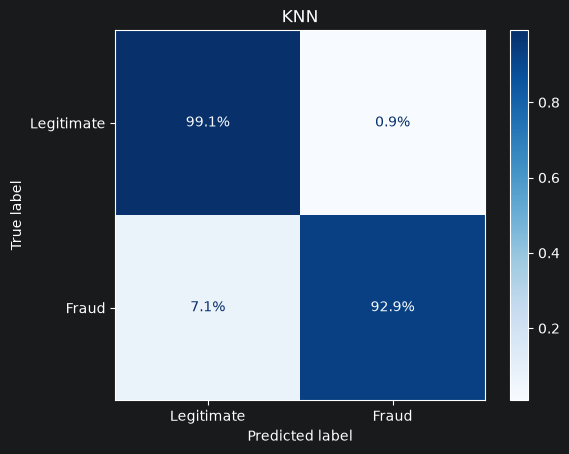

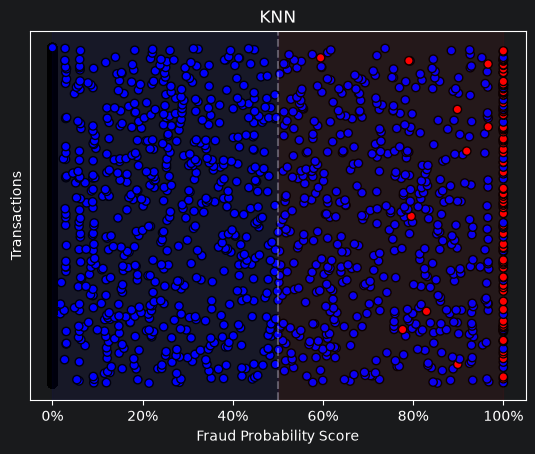

In [9]:
with transactional_mlflow_run(run_name="KNN") as run:
    model_name = "knn"
    run_name_str = str(run.info.run_name)

    def knn_objective(trial: optuna.Trial) -> float:
        knn_params = {
            "n_neighbors": trial.suggest_int("n_neighbors", 1, 30),
            "weights": trial.suggest_categorical(
                "weights", ["uniform", "distance"]
            ),
            "p": trial.suggest_int("p", 1, 2),
            "leaf_size": trial.suggest_int("leaf_size", 60, 120),
        }
        estimator = Pipeline([
            ("robust_scaler", RobustScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            (
                model_name,
                KNeighborsClassifier(**knn_params, n_jobs=-1),
            ),
        ])
        return float(
            numpy.mean(
                cross_val_score(
                    estimator,
                    train_x_np,
                    train_y_np,
                    cv=CV,
                    scoring="average_precision",
                    n_jobs=1,
                )
            )
        )

    knn_study = optimize_hyperparameters(
        objective=knn_objective,
        multivariate=True,
    )
    knn_best_params = knn_study.best_params
    knn_best_model = Pipeline([
        ("robust_scaler", RobustScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        (
            model_name,
            KNeighborsClassifier(**knn_best_params, n_jobs=-1),
        ),
    ]).fit(train_x_np, train_y_np)
    knn_best_model = resolve_proxy_if_cuml_accelerated(knn_best_model)
    _, knn_metrics, knn_figures = evaluate_model(
        model=knn_best_model,
        model_input=test_x_np,
        y_true=test_y_np,
        title=run_name_str,
    )
    print(run_name_str)
    print(f"  Best Hyperparameters: {knn_best_params}")
    display(pandas.DataFrame(knn_metrics.items(), columns=["Metric", "Score"]))
    knn_model_info = log_model_run(
        model=knn_best_model,
        registered_model_name=run_name_str,
        signature=infer_signature(
            model_input=test_x_np,
            model_output=knn_best_model.predict(test_x_np),
        ),
        input_example=test_x_np[:5],
        pip_requirements=[
            "imbalanced-learn==0.14.2",
            "scikit-learn==1.9.0",
            "numpy==2.4.6",
            "pandas==2.3.3",
        ],
        skops_trusted_types=[
            "imblearn.over_sampling._smote.base.SMOTE",
            "imblearn.pipeline.Pipeline",
            "sklearn.metrics._dist_metrics.EuclideanDistance64",
            "sklearn.neighbors._kd_tree.KDTree",
            "sklearn.neighbors._classification.KNeighborsClassifier",
        ],
        params=knn_best_params,
        metrics=knn_metrics,
        figures=knn_figures,
    )

### Random Forest


C:\Users\Reaven\AppData\Local\Temp\ipykernel_16416\3265611493.py:7: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=TPESampler(
[I 2026-10-07 10:04:05,011] A new study created in memory with name: no-name-5fb21d2b-509b-4b98-a2f7-246979a4d962
  0%|          | 0/30 [00:00<?, ?it/s][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 175 out of 175 | elapsed:   24.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 175 out of 175 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 175 out of 175 | elapsed:   19.8s finishe

[I 2026-10-07 10:05:31,092] Trial 0 finished with value: 0.8341908612490726 and parameters: {'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_samples': 0.5290418060840998}. Best is trial 0 with value: 0.8341908612490726.


Best trial: 0. Best value: 0.834191:   3%|▎         | 1/30 [01:26<41:43, 86.31s/it, 86.31/3600 seconds][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   19.6s
[Parallel(n_jobs=-1)]: Done 274 out of 274 | elapsed:   30.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 274 out of 274 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-1)]: Done 274 out of 274 | elapsed:   30.4s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 conc

[I 2026-10-07 10:07:36,234] Trial 1 finished with value: 0.8158553118434881 and parameters: {'n_estimators': 274, 'max_depth': 11, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_samples': 0.6061695553391381}. Best is trial 0 with value: 0.8341908612490726.


Best trial: 0. Best value: 0.834191:   7%|▋         | 2/30 [03:31<50:56, 109.16s/it, 211.46/3600 seconds][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 136 out of 136 | elapsed:   13.6s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 136 out of 136 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 136 out of 136 | elapsed:   13.6s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 136 out of 136 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backen

...

building tree 148 of 287
building tree 149 of 287
building tree 150 of 287
building tree 151 of 287
building tree 152 of 287
building tree 153 of 287
building tree 154 of 287
building tree 155 of 287
building tree 156 of 287
building tree 157 of 287
building tree 158 of 287
building tree 159 of 287
building tree 160 of 287
building tree 161 of 287
building tree 162 of 287
building tree 163 of 287
building tree 164 of 287
building tree 165 of 287
building tree 166 of 287
building tree 167 of 287
building tree 168 of 287
building tree 169 of 287
building tree 170 of 287
building tree 171 of 287
building tree 172 of 287
building tree 173 of 287
building tree 174 of 287
building tree 175 of 287
building tree 176 of 287
building tree 177 of 287
building tree 178 of 287
building tree 179 of 287
building tree 180 of 287
building tree 181 of 287
building tree 182 of 287
building tree 183 of 287
building tree 184 of 287
building tree 185 of 287
building tree 186 of 287
building tree 187 of 287


[Parallel(n_jobs=-1)]: Done 287 out of 287 | elapsed:  1.1min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 287 out of 287 | elapsed:    0.0s finished


Random_Forest
  Best Hyperparameters: {'n_estimators': 287, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_samples': 0.8888952850798094}


,Metric,Score
0,F1 score,0.719665
1,PR-AUC,0.852987
2,Recall,0.877551
3,Precision,0.609929
4,ROC-AUC,0.983618
5,Accuracy,0.998824


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 287 out of 287 | elapsed:    0.0s finished
2026/10/07 11:01:29 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in C:\Users\Reaven\Projects\Personal\Practice\fraud-detection-platform\notebooks
2026/10/07 11:01:30 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - numpy (current: 2.4.6, required: numpy==2.5.2)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2026/10/07 11:01:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec withou

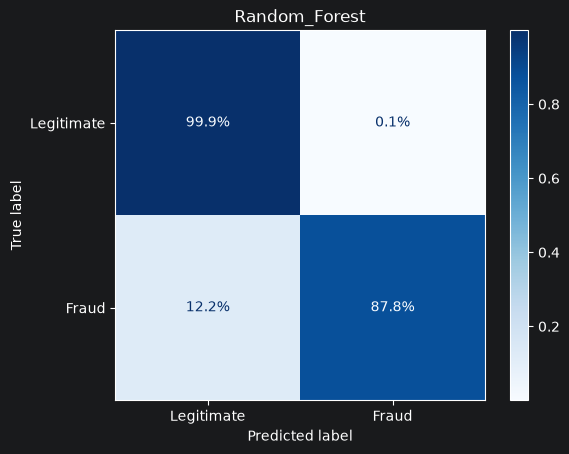

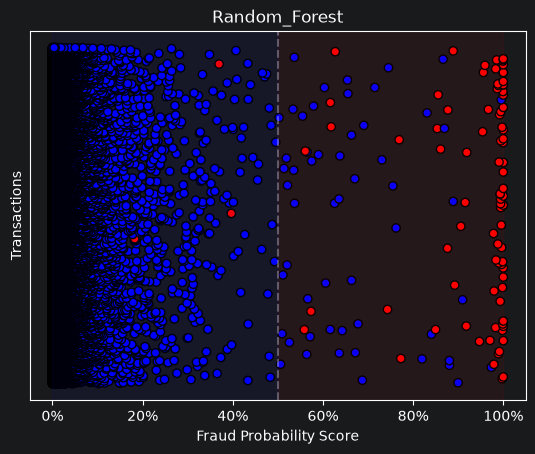

In [10]:
with transactional_mlflow_run(run_name="Random_Forest") as run:
    model_name = "rf"
    run_name_str = str(run.info.run_name)

    def rf_objective(trial: optuna.Trial) -> float:
        rf_params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300),
            "max_depth": trial.suggest_int("max_depth", 5, 15),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features": trial.suggest_categorical(
                "max_features", ["sqrt", "log2"]
            ),
            "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
        }
        # No class_weight: SMOTE already balances the classes, so "balanced" was a no-op,
        # and cuML only runs RandomForestClassifier on the GPU when class_weight is unset.
        estimator = Pipeline([
            ("robust_scaler", RobustScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            (
                model_name,
                RandomForestClassifier(
                    **rf_params,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=1,
                ),
            ),
        ])
        return float(
            numpy.mean(
                cross_val_score(
                    estimator,
                    train_x_np,
                    train_y_np,
                    cv=CV,
                    scoring="average_precision",
                    n_jobs=1,
                )
            )
        )

    rf_study = optimize_hyperparameters(
        objective=rf_objective,
        multivariate=True,
    )
    rf_best_params = rf_study.best_params
    rf_best_model = Pipeline([
        ("robust_scaler", RobustScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        (
            model_name,
            RandomForestClassifier(
                **rf_best_params,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=2,
            ),
        ),
    ]).fit(train_x_np, train_y_np)
    rf_best_model = resolve_proxy_if_cuml_accelerated(rf_best_model)
    _, rf_metrics, rf_figures = evaluate_model(
        model=rf_best_model,
        model_input=test_x_np,
        y_true=test_y_np,
        title=run_name_str,
    )
    print(run_name_str)
    print(f"  Best Hyperparameters: {rf_best_params}")
    display(pandas.DataFrame(rf_metrics.items(), columns=["Metric", "Score"]))
    rf_model_info = log_model_run(
        model=rf_best_model,
        registered_model_name=run_name_str,
        signature=infer_signature(
            model_input=test_x_np,
            model_output=rf_best_model.predict(test_x_np),
        ),
        input_example=test_x_np[:5],
        pip_requirements=[
            "imbalanced-learn==0.14.2",
            "scikit-learn==1.9.0",
            "numpy==2.4.6",
            "pandas==2.3.3",
        ],
        skops_trusted_types=[
            "imblearn.over_sampling._smote.base.SMOTE",
            "imblearn.pipeline.Pipeline",
            "sklearn.ensemble._forest.RandomForestClassifier",
            "sklearn.tree._classes.DecisionTreeClassifier",
            "sklearn.tree._tree.Tree",
        ],
        params=rf_best_params,
        metrics=rf_metrics,
        figures=rf_figures,
    )

### XGBoost


C:\Users\Reaven\AppData\Local\Temp\ipykernel_16416\3265611493.py:7: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=TPESampler(
[I 2026-10-07 11:01:33,246] A new study created in memory with name: no-name-e33286f4-f53d-45af-9b87-cab24d4995ac
  0%|          | 0/30 [00:00<?, ?it/s]

[11:01:40] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (341176, 30, 10235280).
[11:01:40] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:173: Ellpack is dense.


C:\Users\Reaven\Projects\Personal\Practice\fraud-detection-platform\notebooks\.venv\Lib\site-packages\xgboost\core.py:569: UserWarning: [11:01:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[11:01:41] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (341176, 30, 10235280).
[11:01:41] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:173: Ellpack is dense.
[11:01:43] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (341176, 30, 10235280).
[11:01:43] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:173: Ellpack is dense.
[11:01:44] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (341178, 30, 10235340).
[11:01:44] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:173: Ellpack is dense.


  0%|          | 0/30 [00:12<?, ?it/s]

...

[I 2026-10-07 11:05:43,799] Trial 29 finished with value: 0.8436870951412065 and parameters: {'n_estimators': 432, 'max_depth': 10, 'learning_rate': 0.0705666691465318, 'subsample': 0.7906709613236418, 'colsample_bytree': 0.7107673316407063, 'reg_alpha': 1.2319483794136365e-06, 'reg_lambda': 0.00014274273599892715, 'gamma': 3.7958404345270393, 'min_child_weight': 6}. Best is trial 22 with value: 0.8494538787221835.


Best trial: 22. Best value: 0.849454: 100%|██████████| 30/30 [04:10<00:00,  8.36s/it, 250.80/3600 seconds]


[11:05:44] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (454902, 30, 13647060).
[11:05:44] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:173: Ellpack is dense.
XGBoost
  Best Hyperparameters: {'n_estimators': 492, 'max_depth': 10, 'learning_rate': 0.04471326303040307, 'subsample': 0.8424941495643504, 'colsample_bytree': 0.7524934863193213, 'reg_alpha': 4.032960691233195e-06, 'reg_lambda': 0.0002563490778603876, 'gamma': 3.9923739515737875, 'min_child_weight': 2}


,Metric,Score
0,F1 score,0.761062
1,PR-AUC,0.865725
2,Recall,0.877551
3,Precision,0.671875
4,ROC-AUC,0.979455
5,Accuracy,0.999052


2026/10/07 11:05:46 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in C:\Users\Reaven\Projects\Personal\Practice\fraud-detection-platform\notebooks
2026/10/07 11:05:47 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - numpy (current: 2.4.6, required: numpy==2.5.2)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2026/10/07 11:05:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/10/07 11:05:47 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - numpy (current: 2.4.6, required: numpy==2.5.2)
To fix the mismatches, call `mlflow.pyfunc

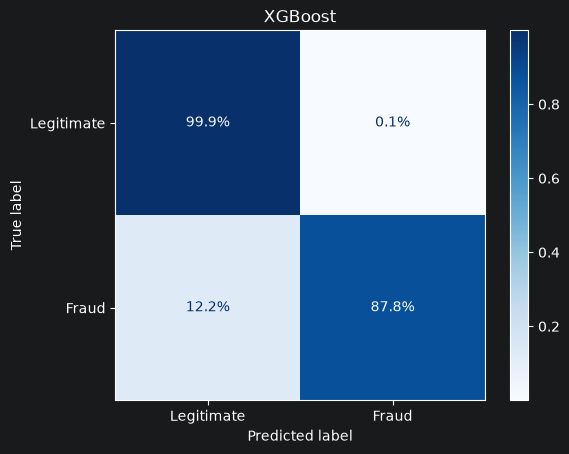

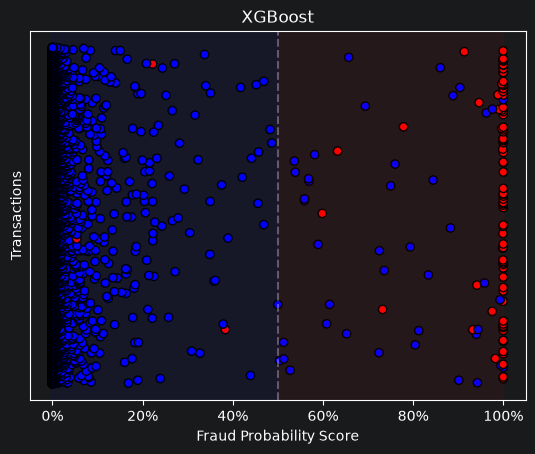

In [11]:
with transactional_mlflow_run(run_name="XGBoost") as run:
    model_name = "xgb"
    run_name_str = str(run.info.run_name)

    def xgb_objective(trial: optuna.Trial) -> float:
        xgb_params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.005, 0.3, log=True
            ),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.4, 1.0
            ),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 1.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 5.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        }
        estimator = Pipeline([
            ("robust_scaler", RobustScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            (
                model_name,
                XGBClassifier(
                    **xgb_params,
                    device="cuda",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbosity=2,
                ),
            ),
        ])
        return float(
            numpy.mean(
                cross_val_score(
                    estimator,
                    train_x_np,
                    train_y_np,
                    cv=CV,
                    scoring="average_precision",
                    n_jobs=1,
                )
            )
        )

    xgb_study = optimize_hyperparameters(
        objective=xgb_objective,
        multivariate=True,
    )
    xgb_best_params = xgb_study.best_params
    xgb_best_model = Pipeline([
        ("robust_scaler", RobustScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        (
            model_name,
            XGBClassifier(
                **xgb_best_params,
                device="cuda",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=2,
            ),
        ),
    ]).fit(train_x_np, train_y_np)
    _, xgb_metrics, xgb_figures = evaluate_model(
        model=xgb_best_model,
        model_input=test_x_np,
        y_true=test_y_np,
        title=run_name_str,
    )
    print(run_name_str)
    print(f"  Best Hyperparameters: {xgb_best_params}")
    display(pandas.DataFrame(xgb_metrics.items(), columns=["Metric", "Score"]))
    xgb_model_info = log_model_run(
        model=xgb_best_model,
        registered_model_name=run_name_str,
        signature=infer_signature(
            model_input=test_x_np,
            model_output=xgb_best_model.predict(test_x_np),
        ),
        input_example=test_x_np[:5],
        pip_requirements=[
            "imbalanced-learn==0.14.2",
            "xgboost==3.4.1",
            "scikit-learn==1.9.0",
            "numpy==2.4.6",
            "pandas==2.3.3",
        ],
        skops_trusted_types=[
            "imblearn.over_sampling._smote.base.SMOTE",
            "imblearn.pipeline.Pipeline",
            "sklearn.metrics._dist_metrics.EuclideanDistance64",
            "sklearn.neighbors._kd_tree.KDTree",
            "xgboost.core.Booster",
            "xgboost.sklearn.XGBClassifier",
        ],
        params=xgb_best_params,
        metrics=xgb_metrics,
        figures=xgb_figures,
    )

### MLP Model


In [12]:
class MLP(nn.Module):
    def __init__(
        self,
        *,
        input_size: int,
        hidden_size: int,
        num_layers: int,
        activation: str,
        dropout: float,
        epochs: int,
        batch_size: int,
        lr: float,
        weight_decay: float,
        device: torch.device,
    ) -> None:
        super().__init__()
        activation_function = ACTIVATION_MAP[activation]

        self.linears = nn.ModuleList()
        self.activations = nn.ModuleList()
        layer_input_size = input_size
        for _ in range(num_layers):
            self.linears.append(nn.Linear(layer_input_size, hidden_size))
            self.activations.append(activation_function())
            layer_input_size = hidden_size
        self.output = nn.Linear(layer_input_size, 1)

        self.dropout = dropout
        self.epochs = epochs
        self.batch_size = batch_size
        self.criterion = nn.BCEWithLogitsLoss()
        self.device = device
        self.to(device)
        self.optimizer = optim.AdamW(
            self.parameters(), lr=lr, weight_decay=weight_decay
        )

    def forward(self, x: Tensor) -> Tensor:
        for linear, activation in zip(self.linears, self.activations):
            x = activation(linear(x))
            x = functional.dropout(x, p=self.dropout, training=self.training)
        return self.output(x).squeeze(1)

    def train_one_epoch(self, train_loader: DataLoader) -> float:
        epoch_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(self.device)
            batch_y = batch_y.to(self.device)
            self.optimizer.zero_grad()
            batch_logits = self(batch_x)
            loss = self.criterion(batch_logits, batch_y)
            loss.backward()
            self.optimizer.step()
            epoch_loss += loss.item()
        return epoch_loss / len(train_loader)

    def update_progress_bar(
        self,
        pbar: tqdm | None,
        epoch: int,
        epoch_loss: float,
    ) -> None:
        if pbar is not None:
            with pbar.get_lock():
                pbar.reset(total=self.epochs)
                pbar.n = epoch + 1
                pbar.set_postfix(loss=f"{epoch_loss:.4f}")

    def fit(
        self,
        x: ndarray,
        y: ndarray,
        pbar: tqdm | None = None,
    ) -> "MLP":
        train_loader = DataLoader(
            TensorDataset(
                torch.tensor(x, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32),
            ),
            batch_size=self.batch_size,
            shuffle=True,
            pin_memory=self.device.type == "cuda",
        )
        self.train()
        for epoch in range(self.epochs):
            epoch_loss = self.train_one_epoch(train_loader=train_loader)
            self.update_progress_bar(
                pbar=pbar,
                epoch=epoch,
                epoch_loss=epoch_loss,
            )
        return self

    def predict_probabilities(self, x: ndarray) -> ndarray:
        self.eval()
        with torch.no_grad():
            tensor = torch.tensor(x, dtype=torch.float32).to(self.device)
            probability = torch.sigmoid(self(tensor)).cpu().numpy()
            return numpy.stack([1 - probability, probability], axis=1)

    def predict(self, x: ndarray, threshold: float = 0.5) -> ndarray:
        probability = self.predict_probabilities(x)[:, 1]
        return (probability >= threshold).astype(int)

    def predict_proba(self, x: ndarray) -> ndarray:
        return self.predict_probabilities(x)

class MLPPipeline(PythonModel):
    def __init__(self, mlp: MLP, robust_scaler: RobustScaler) -> None:
        self.mlp = mlp
        self.robust_scaler = robust_scaler

    def predict(
        self,
        context: PythonModelContext | None,
        model_input: pandas.DataFrame | numpy.ndarray,
        params: dict[str, Any] | None = None,
    ) -> numpy.ndarray:
        params = params or {}

        if isinstance(model_input, pandas.DataFrame):
            model_input = model_input.values
        model_input = self.robust_scaler.transform(model_input)

        if params.get("probabilities", False):
            return self.mlp.predict_proba(model_input)

        return self.mlp.predict(
            model_input,
            threshold=float(params.get("threshold", 0.5)),
        )

C:\Users\Reaven\Projects\Personal\Practice\fraud-detection-platform\notebooks\.venv\Lib\site-packages\mlflow\pyfunc\model.py:209: UserWarning: Type hint used in the model's predict function is not supported for MLflow's schema validation. Type hints must be wrapped in list[...] because MLflow assumes the predict method to take multiple input instances. Specify your type hint as `list[pandas.core.frame.DataFrame | numpy.ndarray]` for a valid signature. Remove the type hint to disable this warning. To enable validation for the input data, specify input example or model signature when logging the model. 
  func_info = _get_func_info_if_type_hint_supported(predict_attr)


### MLP


MLP: 0it [00:00, ?it/s][I 2026-10-07 11:05:50,381] A new study created in memory with name: no-name-2cb91397-ed12-4141-be38-ff04cae46f36

                                                                 
  0%|          | 0/30 [02:18<?, ?it/s]

[I 2026-10-07 11:08:09,322] Trial 0 finished with value: 0.7405162896236764 and parameters: {'hidden_size': 116, 'num_layers': 4, 'activation': 'relu', 'dropout': 0.07799726016810132, 'lr': 1.7073967431528103e-05, 'weight_decay': 0.011567327199145964, 'batch_size': 320, 'epochs': 8}. Best is trial 0 with value: 0.7405162896236764.



Best trial: 0. Best value: 0.740516:   3%|▎         | 1/30 [02:19<1:07:19, 139.28s/it]
                                                                 <1:07:19, 139.28s/it, 139.28/3600 seconds]
Best trial: 0. Best value: 0.740516:   3%|▎         | 1/30 [04:13<1:07:19, 139.28s/it, 139.28/3600 seconds]

[I 2026-10-07 11:10:03,974] Trial 1 finished with value: 0.7570164845742265 and parameters: {'hidden_size': 36, 'num_layers': 4, 'activation': 'relu', 'dropout': 0.09170225492671691, 'lr': 0.00016480446427978953, 'weight_decay': 4.712973756110775e-05, 'batch_size': 256, 'epochs': 5}. Best is trial 1 with value: 0.7570164845742265.



Best trial: 1. Best value: 0.757016:   7%|▋         | 2/30 [04:13<58:15, 124.83s/it, 139.28/3600 seconds]  
                                                                 <58:15, 124.83s/it, 253.99/3600 seconds]
Best trial: 1. Best value: 0.757016:   7%|▋         | 2/30 [05:01<58:15, 124.83s/it, 253.99/3600 seconds]

...

[I 2026-10-07 12:07:08,066] Trial 29 finished with value: 0.8278683495697455 and parameters: {'hidden_size': 241, 'num_layers': 4, 'activation': 'gelu', 'dropout': 0.2316010087562307, 'lr': 0.00011696766705514469, 'weight_decay': 0.02554980036343082, 'batch_size': 384, 'epochs': 8}. Best is trial 29 with value: 0.8278683495697455.



MLP: 100%|██████████| 8/8 [00:00<00:00, 8000.58it/s, loss=0.0113]

MLP
  Best Hyperparameters: {'hidden_size': 241, 'num_layers': 4, 'activation': 'gelu', 'dropout': 0.2316010087562307, 'lr': 0.00011696766705514469, 'weight_decay': 0.02554980036343082, 'batch_size': 384, 'epochs': 8}


,Metric,Score
0,F1 score,0.427136
1,PR-AUC,0.835925
2,Recall,0.867347
3,Precision,0.283333
4,ROC-AUC,0.975623
5,Accuracy,0.995997


2026/10/07 12:07:50 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in C:\Users\Reaven\Projects\Personal\Practice\fraud-detection-platform\notebooks
2026/10/07 12:07:50 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
C:\Users\Reaven\Projects\Personal\Practice\fraud-detection-platform\notebooks\.venv\Lib\site-packages\mlflow\pyfunc\__init__.py:3271: UserWarning: Failed to infer signature from type hint: Type hints must be wrapped in list[...] because MLflow assumes the predict method to take multiple input instances. Specify your type hint as `list[pandas.core.frame.DataFrame | numpy.ndarray]` for a valid signature.
  signature_from_type_hints = _i

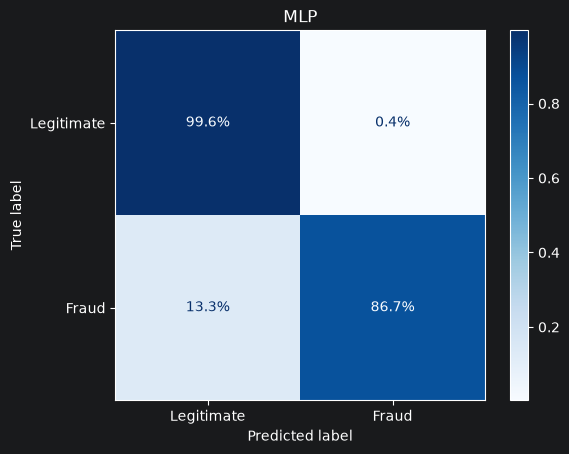

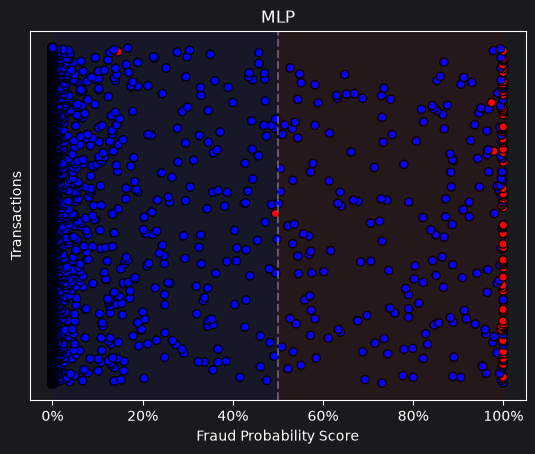

MLP: 100%|██████████| 8/8 [00:02<00:00,  3.12it/s, loss=0.0113]  


In [13]:
def score_mlp_fold(
    *,
    fold_train_x: ndarray,
    fold_train_y: ndarray,
    fold_val_x: ndarray,
    fold_val_y: ndarray,
    mlp_params: dict[str, object],
    pbar: tqdm | None,
) -> float:
    robust_scaler = RobustScaler()
    fold_train_x_scaled = robust_scaler.fit_transform(fold_train_x)
    fold_val_x_scaled = robust_scaler.transform(fold_val_x)

    fold_train_x_scaled, fold_train_y = SMOTE(
        random_state=RANDOM_STATE
    ).fit_resample(fold_train_x_scaled, fold_train_y)

    model = MLP(
        **mlp_params,
        input_size=fold_train_x_scaled.shape[1],
        device=DEVICE,
    ).fit(fold_train_x_scaled, fold_train_y, pbar)

    return average_precision_score(
        fold_val_y,
        model.predict_proba(fold_val_x_scaled)[:, 1],
    )

with transactional_mlflow_run(run_name="MLP") as run:
    run_name_str = str(run.info.run_name)

    with tqdm(desc="MLP", dynamic_ncols=True) as pbar:

        def mlp_objective(trial: optuna.Trial) -> float:
            mlp_params = {
                "hidden_size": trial.suggest_int("hidden_size", 32, 256),
                "num_layers": trial.suggest_int("num_layers", 2, 4),
                "activation": trial.suggest_categorical(
                    "activation", ["relu", "gelu", "silu"]
                ),
                "dropout": trial.suggest_float("dropout", 0.0, 0.5),
                "lr": trial.suggest_float("lr", 1e-5, 0.1, log=True),
                "weight_decay": trial.suggest_float(
                    "weight_decay", 1e-8, 0.1, log=True
                ),
                "batch_size": trial.suggest_int("batch_size", 64, 512, step=64),
                "epochs": trial.suggest_int("epochs", 3, 10),
            }
            fold_scores = []
            for fold_train_indices, fold_val_indices in CV.split(
                train_x_np, train_y_np
            ):
                fold_score = score_mlp_fold(
                    fold_train_x=train_x_np[fold_train_indices],
                    fold_train_y=train_y_np[fold_train_indices],
                    fold_val_x=train_x_np[fold_val_indices],
                    fold_val_y=train_y_np[fold_val_indices],
                    mlp_params=mlp_params,
                    pbar=pbar,
                )
                fold_scores.append(fold_score)
            return float(numpy.mean(fold_scores))

        mlp_study = optimize_hyperparameters(
            objective=mlp_objective,
            multivariate=False,
        )
        mlp_best_params = mlp_study.best_params

        mlp_robust_scaler = RobustScaler()
        train_x_scaled_np = mlp_robust_scaler.fit_transform(train_x_np)
        train_x_scaled_np, train_y_resampled_np = SMOTE(
            random_state=RANDOM_STATE
        ).fit_resample(train_x_scaled_np, train_y_np)
        mlp_best_model = MLPPipeline(
            mlp=MLP(
                **mlp_best_params,
                input_size=train_x_np_dimensions_size,
                device=DEVICE,
            ).fit(train_x_scaled_np, train_y_resampled_np, pbar),
            robust_scaler=mlp_robust_scaler,
        )
        _, mlp_metrics, mlp_figures = evaluate_model(
            model=mlp_best_model,
            model_input=test_x_np,
            y_true=test_y_np,
            title=run_name_str,
        )
        print(run_name_str)
        print(f"  Best Hyperparameters: {mlp_best_params}")
        display(pandas.DataFrame(mlp_metrics.items(), columns=["Metric", "Score"]))
        # Self-contained CPU copy: a model pickled with CUDA weights, a CUDA device and
        # CUDA optimizer state cannot be loaded on a CPU-only machine.
        mlp_best_model.mlp.to("cpu")
        mlp_best_model.mlp.device = torch.device("cpu")
        del mlp_best_model.mlp.optimizer
        mlp_model_info = log_model_run(
            model=mlp_best_model,
            registered_model_name=run_name_str,
            signature=infer_signature(
                model_input=test_x_np,
                model_output=mlp_best_model.predict(
                    context=None,
                    model_input=test_x_np
                ),
                params={"probabilities": False, "threshold": 0.5},
            ),
            input_example=test_x_np[:5],
            pip_requirements=[
                "torch==2.14.1",
                "scikit-learn==1.9.0",
                "numpy==2.4.6",
                "pandas==2.3.3",
            ],
            params=mlp_best_params,
            metrics=mlp_metrics,
            figures=mlp_figures,
        )